In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:/Users/Avika Malik/OneDrive/Documents/export.csv")

# Basic inspection
print(df.shape)              # rows, columns
print(df.columns)  # all column names
print(df.head())             # first 5 rows
print(df.dtypes)             # data types
print(df.info())             #all info

(1048575, 12)
Index(['Age recode with <1 year olds and 90+', 'Sex', 'Year of diagnosis',
       'Site recode ICD-O-3/WHO 2008', 'Grade Clinical (2018+)',
       'Histology recode - broad groupings', 'Primary Site - labeled',
       'Combined Summary Stage with Expanded Regional Codes (2004+)',
       'Tumor Size Summary (2016+)', 'Vital status recode (study cutoff used)',
       'Survival months',
       'COD to site recode ICD-O-3 2023 Revision Expanded (1999+)'],
      dtype='object')
  Age recode with <1 year olds and 90+     Sex  Year of diagnosis  \
0                          40-44 years    Male               2002   
1                          65-69 years    Male               2000   
2                          35-39 years  Female               2008   
3                          60-64 years  Female               2008   
4                            90+ years    Male               2008   

                        Site recode ICD-O-3/WHO 2008 Grade Clinical (2018+)  \
0             

In [2]:
df.rename(columns={
    'Age recode with <1 year olds and 90+' : 'Age',
    'Sex'                                   : 'Sex',
    'Year of diagnosis'                     : 'Year_Diagnosis',
    'Site recode ICD-O-3/WHO 2008'          : 'Site_Recode',
    'Grade Clinical (2018+)'                : 'Grade',
    'Histology recode - broad groupings'    : 'Histology',
    'Primary Site - labeled'               : 'Primary_Site',
    'Combined Summary Stage with Expanded Regional Codes (2004+)'               : 'Stage',
    'Tumor Size Summary (2016+)'           : 'Tumor_Size',
    'Vital status recode (study cutoff used)': 'Vital_Status',
    'Survival months'                      : 'Survival_Months',
    'COD to site recode ICD-O-3 2023 Revision Expanded (1999+)': 'Cause_of_Death'
}, inplace=True)

print(df.columns.tolist())
df

['Age', 'Sex', 'Year_Diagnosis', 'Site_Recode', 'Grade', 'Histology', 'Primary_Site', 'Stage', 'Tumor_Size', 'Vital_Status', 'Survival_Months', 'Cause_of_Death']


,Age,Sex,Year_Diagnosis,Site_Recode,Grade,Histology,Primary_Site,Stage,Tumor_Size,Vital_Status,Survival_Months,Cause_of_Death
0,40-44 years,Male,2002,Testis,Blank(s),9060-9099: germ cell neoplasms,"C62.9-Testis, NOS",Blank(s),Blank(s),Alive,244,Alive
1,65-69 years,Male,2000,Rectum,Blank(s),8140-8389: adenomas and adenocarcinomas,"C20.9-Rectum, NOS",Blank(s),Blank(s),Dead,49,Colon And Rectum (Excluding Appendix)
2,35-39 years,Female,2008,Rectosigmoid Junction,Blank(s),8140-8389: adenomas and adenocarcinomas,C19.9-Rectosigmoid junction,Distant site(s)/node(s) involved,Blank(s),Alive,179,Alive
3,60-64 years,Female,2008,"Trachea, Mediastinum and Other Respiratory Organs",Blank(s),"8800-8809: soft tissue tumors and sarcomas, NOS",C38.1-Anterior mediastinum,Localized only,Blank(s),Dead,0,"Heart, Mediastinum And Pleura"
4,90+ years,Male,2008,Melanoma of the Skin,Blank(s),8720-8799: nevi and melanomas,C44.4-Skin of scalp and neck,Localized only,Blank(s),Dead,26,Other COD
...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,50-54 years,Female,2011,Breast,Blank(s),8500-8549: ductal and lobular neoplasms,C50.5-Lower-outer quadrant of breast,Regional lymph nodes involved only,Blank(s),Alive,71,Alive
1048571,45-49 years,Female,2011,Breast,Blank(s),8140-8389: adenomas and adenocarcinomas,C50.5-Lower-outer quadrant of breast,Localized only,Blank(s),Alive,143,Alive
1048572,60-64 years,Female,2011,Breast,Blank(s),8500-8549: ductal and lobular neoplasms,C50.4-Upper-outer quadrant of breast,Regional lymph nodes involved only,Blank(s),Dead,8,Other COD
1048573,75-79 years,Female,2011,Breast,Blank(s),8500-8549: ductal and lobular neoplasms,C50.4-Upper-outer quadrant of breast,Localized only,Blank(s),Alive,106,Alive


In [3]:
unknown_values = ['Blank(s)', 'Unknown', 'unknown', 
                   'Not applicable', '99', '999', 'NA']
df.replace(unknown_values, np.nan, inplace=True)
df


,Age,Sex,Year_Diagnosis,Site_Recode,Grade,Histology,Primary_Site,Stage,Tumor_Size,Vital_Status,Survival_Months,Cause_of_Death
0,40-44 years,Male,2002,Testis,NaN,9060-9099: germ cell neoplasms,"C62.9-Testis, NOS",NaN,NaN,Alive,244,Alive
1,65-69 years,Male,2000,Rectum,NaN,8140-8389: adenomas and adenocarcinomas,"C20.9-Rectum, NOS",NaN,NaN,Dead,49,Colon And Rectum (Excluding Appendix)
2,35-39 years,Female,2008,Rectosigmoid Junction,NaN,8140-8389: adenomas and adenocarcinomas,C19.9-Rectosigmoid junction,Distant site(s)/node(s) involved,NaN,Alive,179,Alive
3,60-64 years,Female,2008,"Trachea, Mediastinum and Other Respiratory Organs",NaN,"8800-8809: soft tissue tumors and sarcomas, NOS",C38.1-Anterior mediastinum,Localized only,NaN,Dead,0,"Heart, Mediastinum And Pleura"
4,90+ years,Male,2008,Melanoma of the Skin,NaN,8720-8799: nevi and melanomas,C44.4-Skin of scalp and neck,Localized only,NaN,Dead,26,Other COD
...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,50-54 years,Female,2011,Breast,NaN,8500-8549: ductal and lobular neoplasms,C50.5-Lower-outer quadrant of breast,Regional lymph nodes involved only,NaN,Alive,71,Alive
1048571,45-49 years,Female,2011,Breast,NaN,8140-8389: adenomas and adenocarcinomas,C50.5-Lower-outer quadrant of breast,Localized only,NaN,Alive,143,Alive
1048572,60-64 years,Female,2011,Breast,NaN,8500-8549: ductal and lobular neoplasms,C50.4-Upper-outer quadrant of breast,Regional lymph nodes involved only,NaN,Dead,8,Other COD
1048573,75-79 years,Female,2011,Breast,NaN,8500-8549: ductal and lobular neoplasms,C50.4-Upper-outer quadrant of breast,Localized only,NaN,Alive,106,Alive


In [4]:
missing_count = df.isnull().sum()
total_rows=len(df)
missing_perct= (missing_count/total_rows *100).round(2)
missing_df = pd.DataFrame({
    'Missing Count' : missing_count,'Missing %' : missing_perct})
print(missing_df[missing_df['Missing Count'] > 0])

                 Missing Count  Missing %
Grade                   816613      77.88
Stage                   175965      16.78
Tumor_Size              851046      81.16
Survival_Months          15104       1.44


In [5]:
cols_to_fix=['Grade','Tumor_Size','Stage','Survival_Months']
df.dropna(subset=cols_to_fix,inplace=True)
df.reset_index(drop=True,inplace=True)
print(df.columns)
print(df.shape)
df

Index(['Age', 'Sex', 'Year_Diagnosis', 'Site_Recode', 'Grade', 'Histology',
       'Primary_Site', 'Stage', 'Tumor_Size', 'Vital_Status',
       'Survival_Months', 'Cause_of_Death'],
      dtype='object')
(141223, 12)


,Age,Sex,Year_Diagnosis,Site_Recode,Grade,Histology,Primary_Site,Stage,Tumor_Size,Vital_Status,Survival_Months,Cause_of_Death
0,70-74 years,Female,2018,Breast,9,8500-8549: ductal and lobular neoplasms,C50.8-Overlapping lesion of breast,Localized only,24,Alive,59,Alive
1,60-64 years,Female,2019,Corpus Uteri,9,8140-8389: adenomas and adenocarcinomas,C54.1-Endometrium,Localized only,1,Alive,39,Alive
2,65-69 years,Male,2018,Lung and Bronchus,2,8140-8389: adenomas and adenocarcinomas,"C34.1-Upper lobe, lung",Regional by both direct extension and lymph no...,70,Alive,59,Alive
3,75-79 years,Female,2021,Pancreas,9,8500-8549: ductal and lobular neoplasms,C25.0-Head of pancreas,Regional by both direct extension and lymph no...,28,Alive,15,Alive
4,65-69 years,Female,2022,Stomach,9,8930-8999: complex mixed and stromal neoplasms,C16.3-Gastric antrum,Localized only,28,Alive,7,Alive
...,...,...,...,...,...,...,...,...,...,...,...,...
141218,40-44 years,Female,2019,Breast,3,8500-8549: ductal and lobular neoplasms,C50.2-Upper-inner quadrant of breast,Localized only,12,Alive,41,Alive
141219,80-84 years,Female,2018,Lung and Bronchus,9,8140-8389: adenomas and adenocarcinomas,"C34.1-Upper lobe, lung",Localized only,36,Dead,34,Lung And Bronchus
141220,70-74 years,Female,2021,Small Intestine,9,8930-8999: complex mixed and stromal neoplasms,C17.1-Jejunum,Localized only,23,Alive,18,Alive
141221,65-69 years,Female,2020,Lung and Bronchus,9,8140-8389: adenomas and adenocarcinomas,"C34.1-Upper lobe, lung",Distant site(s)/node(s) involved,24,Alive,28,Alive


In [6]:
cols=['Grade','Tumor_Size','Survival_Months']
for col in cols:
    df[col]=pd.to_numeric(df[col],errors='coerce')
    df[col]=df[col].fillna(0).astype(int)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141223 entries, 0 to 141222
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Age              141223 non-null  object
 1   Sex              141223 non-null  object
 2   Year_Diagnosis   141223 non-null  int64 
 3   Site_Recode      141223 non-null  object
 4   Grade            141223 non-null  int64 
 5   Histology        141223 non-null  object
 6   Primary_Site     141223 non-null  object
 7   Stage            141223 non-null  object
 8   Tumor_Size       141223 non-null  int64 
 9   Vital_Status     141223 non-null  object
 10  Survival_Months  141223 non-null  int64 
 11  Cause_of_Death   141223 non-null  object
dtypes: int64(4), object(8)
memory usage: 12.9+ MB
None


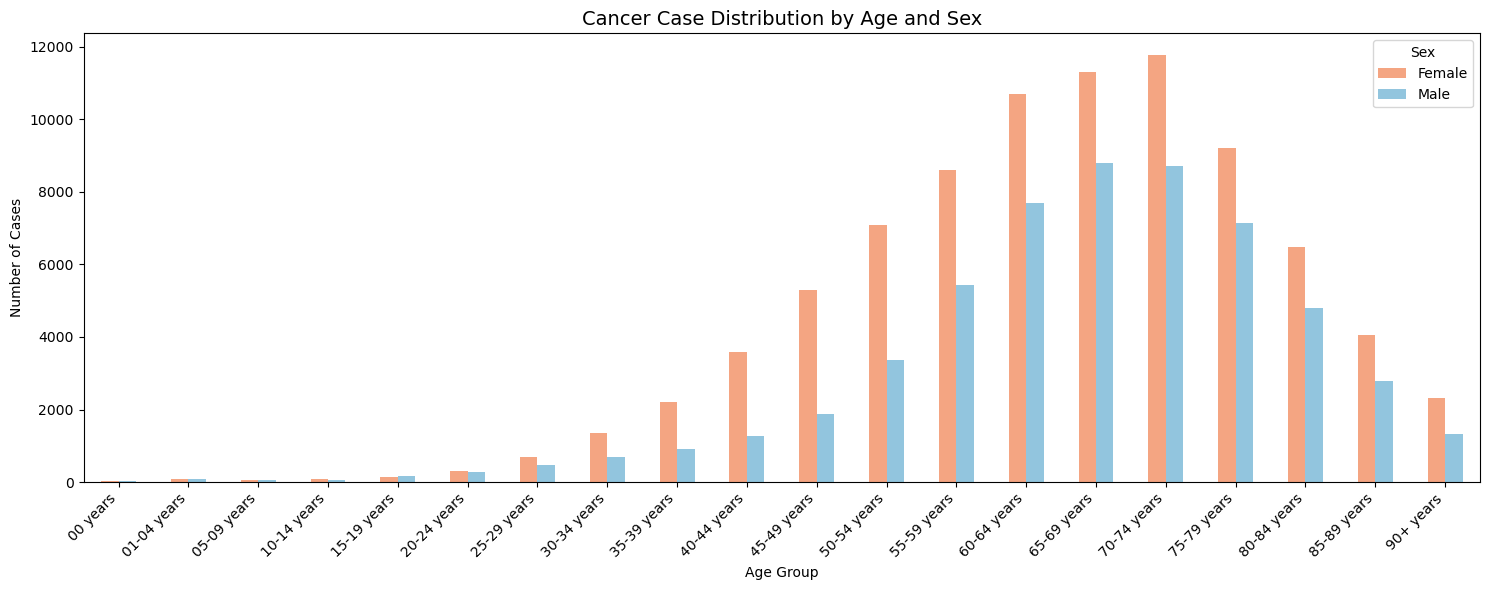

In [7]:
df.groupby(['Age', 'Sex']).size().unstack().plot(
    kind='bar',
    figsize=(15, 6),
    color=['#f4a582', '#92c5de']  # pink for Female, blue for Male
)

plt.title('Cancer Case Distribution by Age and Sex', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

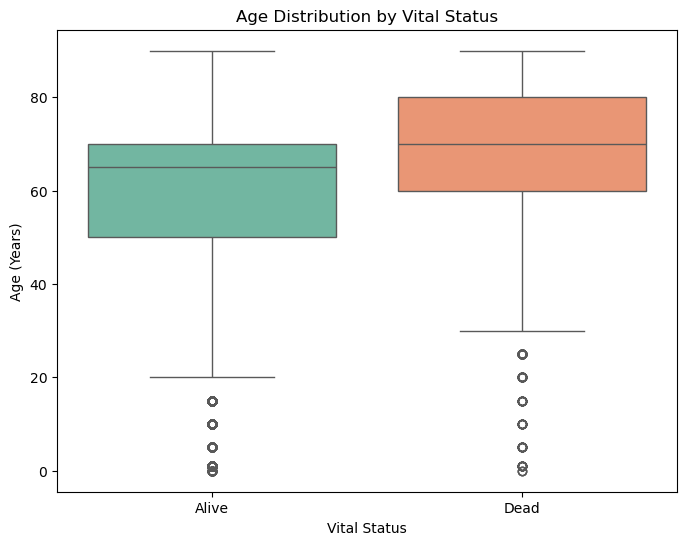

In [8]:
# 1. Convert categorical Age (e.g., '40-44') to a number (takes the first number)
# This is necessary because boxplots require numerical values for the Y-axis.
df['Age_Numeric'] = df['Age'].str.extract('(\d+)').astype(float)

# 2. Create the Box Plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Vital_Status', y='Age_Numeric',hue='Vital_Status', palette='Set2')

# 3. Add labels
plt.title('Age Distribution by Vital Status')
plt.xlabel('Vital Status')
plt.ylabel('Age (Years)')

plt.show()

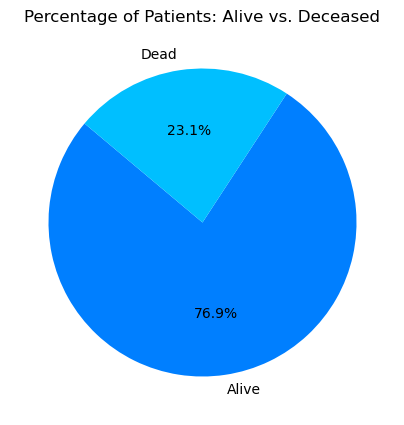

In [9]:

# 1. Count the occurrences of each status
status_counts = df['Vital_Status'].value_counts()

# 2. Create the Pie Chart
plt.figure(figsize=(5, 5))
plt.pie(status_counts, 
        labels=status_counts.index, 
        autopct='%1.1f%%', 
        colors=['#007fff','#00bfff'], 
        startangle=140)

plt.title('Percentage of Patients: Alive vs. Deceased')
plt.show()

In [10]:
site_counts=df['Primary_Site'].value_counts()
print(site_counts)
top_10_sites=site_counts.head(10).index
print(top_10_sites)
df_top_10=df[df['Primary_Site'].isin(top_10_sites)]
df_top_10


Primary_Site
C50.4-Upper-outer quadrant of breast                  12847
C34.1-Upper lobe, lung                                11399
C50.8-Overlapping lesion of breast                     9134
C61.9-Prostate gland                                   6696
C64.9-Kidney, NOS                                      6690
                                                      ...  
C69.8-Overlapping lesion of eye and adnexa                1
C63.8-Overlapping lesion of male genital organs           1
C72.5-Cranial nerve, NOS                                  1
C63.7-Other specified parts of male genital organs        1
C21.2-Cloacogenic zone                                    1
Name: count, Length: 295, dtype: int64
Index(['C50.4-Upper-outer quadrant of breast', 'C34.1-Upper lobe, lung',
       'C50.8-Overlapping lesion of breast', 'C61.9-Prostate gland',
       'C64.9-Kidney, NOS', 'C34.3-Lower lobe, lung', 'C73.9-Thyroid gland',
       'C54.1-Endometrium', 'C50.2-Upper-inner quadrant of breast',
 

,Age,Sex,Year_Diagnosis,Site_Recode,Grade,Histology,Primary_Site,Stage,Tumor_Size,Vital_Status,Survival_Months,Cause_of_Death,Age_Numeric
0,70-74 years,Female,2018,Breast,9,8500-8549: ductal and lobular neoplasms,C50.8-Overlapping lesion of breast,Localized only,24,Alive,59,Alive,70.0
1,60-64 years,Female,2019,Corpus Uteri,9,8140-8389: adenomas and adenocarcinomas,C54.1-Endometrium,Localized only,1,Alive,39,Alive,60.0
2,65-69 years,Male,2018,Lung and Bronchus,2,8140-8389: adenomas and adenocarcinomas,"C34.1-Upper lobe, lung",Regional by both direct extension and lymph no...,70,Alive,59,Alive,65.0
10,65-69 years,Female,2018,Breast,2,8500-8549: ductal and lobular neoplasms,C50.4-Upper-outer quadrant of breast,Localized only,8,Alive,54,Alive,65.0
11,70-74 years,Female,2021,Corpus Uteri,3,8930-8999: complex mixed and stromal neoplasms,C54.1-Endometrium,Localized only,64,Alive,22,Alive,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
141216,80-84 years,Male,2018,Lung and Bronchus,9,8140-8389: adenomas and adenocarcinomas,"C34.1-Upper lobe, lung",Regional by direct extension only,10,Dead,32,Ischemic heart disease,80.0
141218,40-44 years,Female,2019,Breast,3,8500-8549: ductal and lobular neoplasms,C50.2-Upper-inner quadrant of breast,Localized only,12,Alive,41,Alive,40.0
141219,80-84 years,Female,2018,Lung and Bronchus,9,8140-8389: adenomas and adenocarcinomas,"C34.1-Upper lobe, lung",Localized only,36,Dead,34,Lung And Bronchus,80.0
141221,65-69 years,Female,2020,Lung and Bronchus,9,8140-8389: adenomas and adenocarcinomas,"C34.1-Upper lobe, lung",Distant site(s)/node(s) involved,24,Alive,28,Alive,65.0


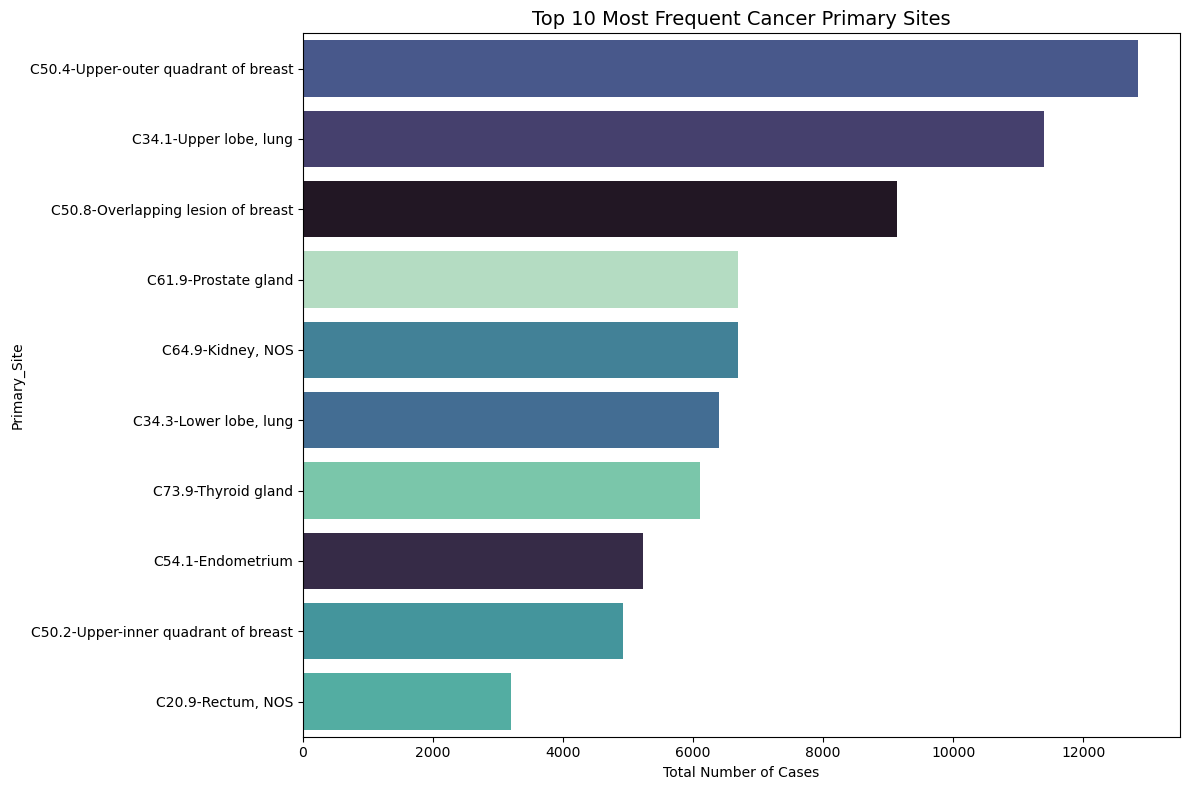

In [11]:
plt.figure(figsize=(12, 8))
sns.countplot(
    data=df_top_10, 
    y='Primary_Site', 
    order=top_10_sites, 
    hue='Primary_Site', 
    palette='mako', 
    legend=False
)
plt.title('Top 10 Most Frequent Cancer Primary Sites', fontsize=14)
plt.xlabel('Total Number of Cases')
plt.tight_layout()
plt.show()

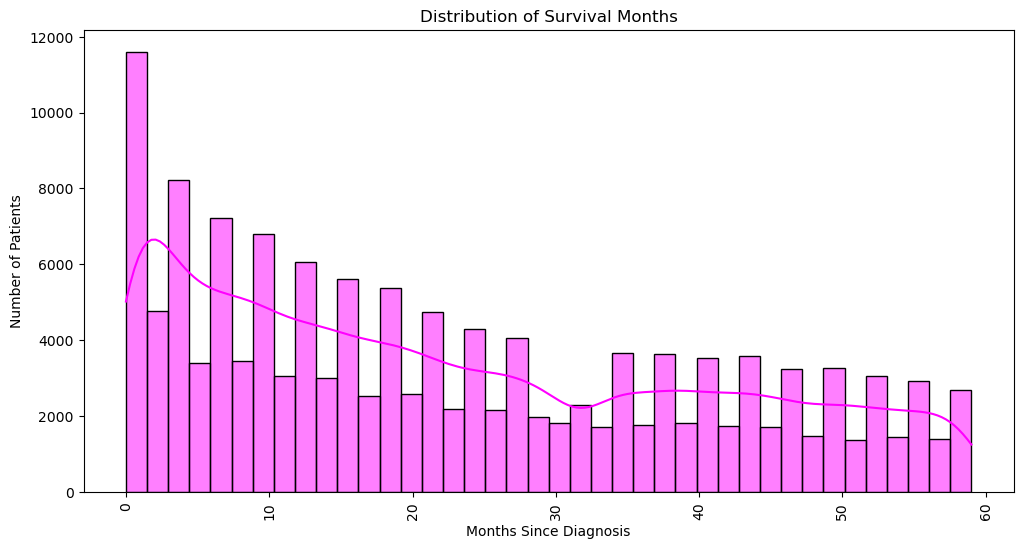

In [12]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df, x='Survival_Months', bins=40, kde=True, color='magenta')

plt.title('Distribution of Survival Months')
plt.xlabel('Months Since Diagnosis')
plt.ylabel('Number of Patients')
plt.xticks(rotation=90)
plt.show()

Age_Numeric        float64
Tumor_Size           int64
Survival_Months      int64
dtype: object
Correlation Matrix:
                  Age_Numeric  Tumor_Size  Survival_Months
Age_Numeric         1.000000    0.003908        -0.148272
Tumor_Size          0.003908    1.000000        -0.060837
Survival_Months    -0.148272   -0.060837         1.000000

Covariance Matrix:
                  Age_Numeric   Tumor_Size  Survival_Months
Age_Numeric       213.883778     4.321063       -37.844452
Tumor_Size          4.321063  5716.405439       -80.275212
Survival_Months   -37.844452   -80.275212       304.584997


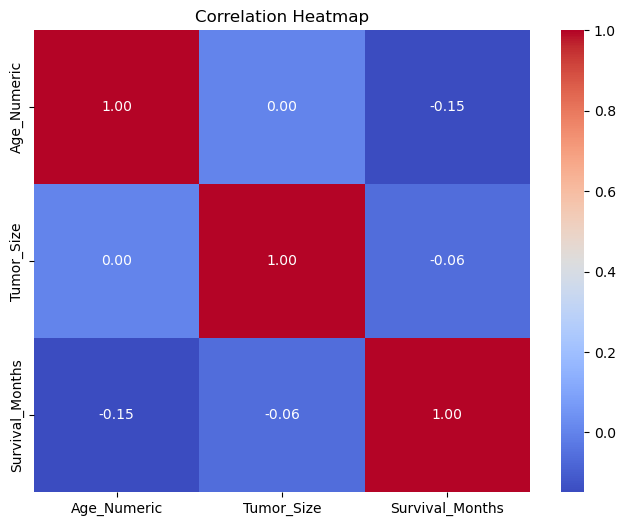

In [13]:
# 1. Select the numeric columns
cols = ['Age_Numeric', 'Tumor_Size', 'Survival_Months']

data_subset=df[cols]
print(data_subset.dtypes)
# 2. Get the Matrices
cor_matrix = data_subset.corr()
cov_matrix = data_subset.cov()
# 3. Print the results
print("Correlation Matrix:\n", cor_matrix)
print("\nCovariance Matrix:\n", cov_matrix)

# 4. Plot the Heatmap (Standard for reports)
plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

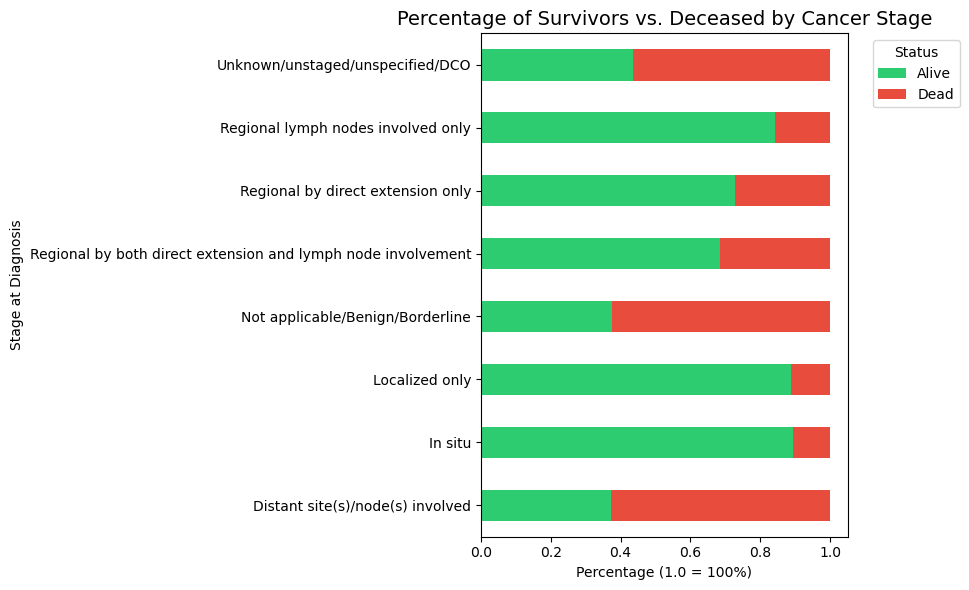

In [14]:
stage_status = pd.crosstab(df['Stage'], 
                           df['Vital_Status'], 
                           normalize='index')

# 2. Plot as a horizontal stacked bar chart
stage_status.plot(kind='barh', 
                  stacked=True, 
                  color=['#2ecc71', '#e74c3c'], # Green for Alive, Red for Dead
                  figsize=(10, 6))

# 3. Add labels
plt.title('Percentage of Survivors vs. Deceased by Cancer Stage', fontsize=14)
plt.xlabel('Percentage (1.0 = 100%)')
plt.ylabel('Stage at Diagnosis')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()
#in situ- cancer is only in original location, hasn't spread at all
#localised only- confined to organ where starts
#by direct extension- spread to nearby tissue
#lymph nodes- spread to nearby lymph nodes